# Road Crack Detection using OpenCV for Image Analysis
---

### Importing Required Libraries

In [3]:
# Essential Libraries Import
import cv2
import numpy as np
import matplotlib.pyplot as plt

---
### Image Enhancement & Edge Isolation

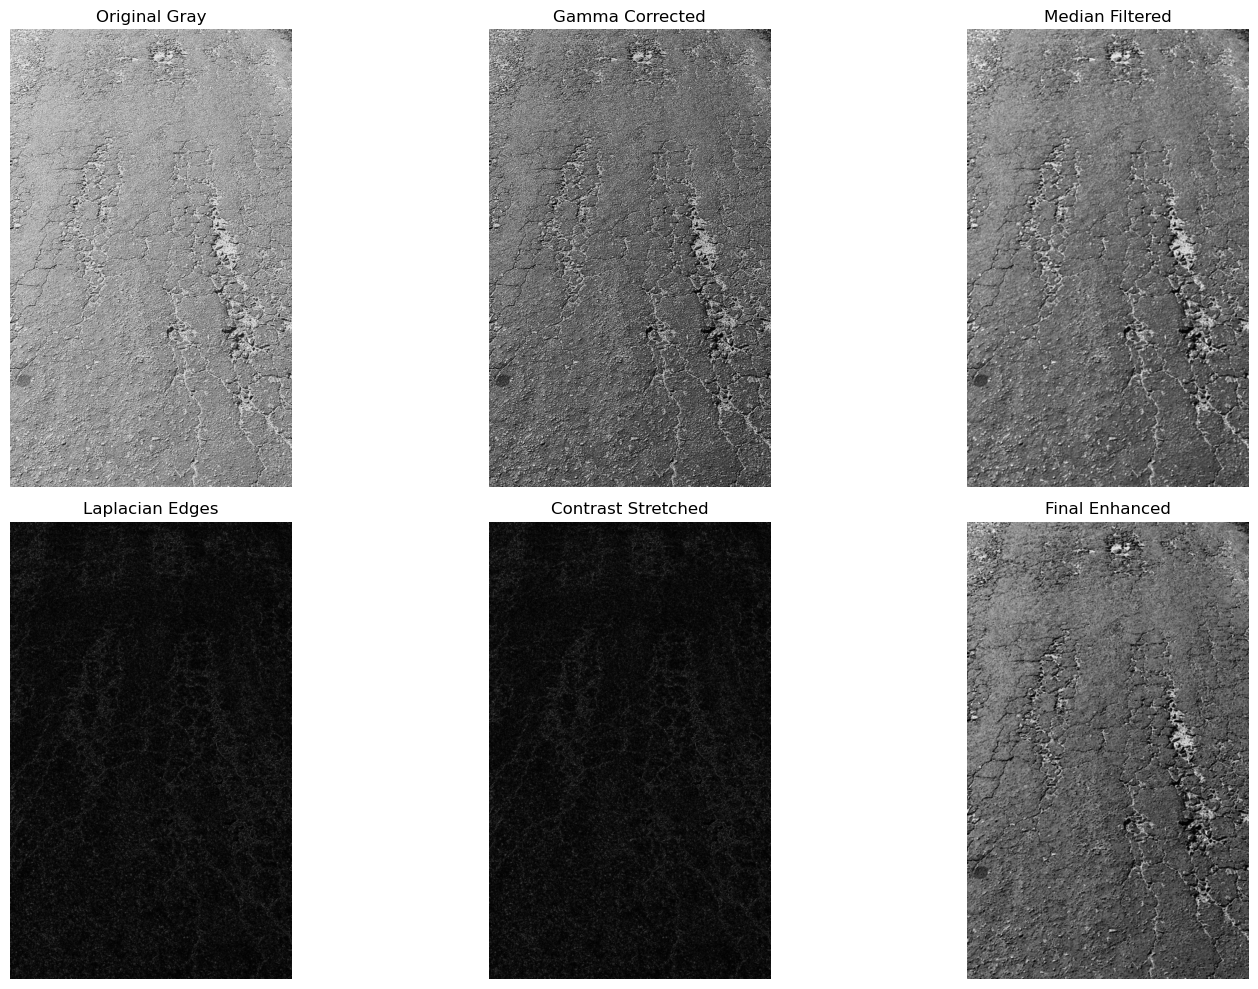

In [42]:
# load image and check if it sucessfully load or not.else part continue the program
image = cv2.imread("f.jpg")  
if image is None:
    print("Error: Image not found. Please check the file path.")
else:
    # convert image to gray scale to reduce the computation power and time
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Power-Law (Gamma) Transformation
    # Used to increase contrast by darkening pixels.
    # This makes road cracks appear much darker and easier to detect.
    gamma = 2.0
    gamma_corrected = np.array(255 * (gray / 255) ** gamma, dtype='uint8')

    # Median Filtering (Noise Reduction)
    # Used to remove small dots, sand, and salt-and-pepper noise.
    # This smooths the road surface while preserving the sharp edges of the cracks.
    median_filtered = cv2.medianBlur(gamma_corrected, 5)

    # Laplacian Sharpening
    # Used to detect intensity changes and highlight the edges of the cracks.
    # It makes the crack boundaries appear as bright white lines against the background.
    laplacian = cv2.Laplacian(median_filtered, cv2.CV_64F)
    sharpened_edges = np.uint8(np.absolute(laplacian))

    # Min-Max Normalization (Contrast Stretching)
    # Used to expand the pixel range to the full 0-255 scale.
    # This makes the faint crack edges much brighter and more distinct.
    stretched = cv2.normalize(sharpened_edges, None, 0, 255, cv2.NORM_MINMAX)

    # Image Subtraction
    # Used to darken the crack areas by subtracting the bright edges from the filtered image.
    # Since the cracks are now represented by white pixels (high values) in the 'stretched' image,
    # subtracting them from the original makes those specific areas turn black.
    final_enhanced = cv2.subtract(median_filtered, stretched)

    # Final Normalization (Optional)
    # Used to stretch the pixel intensity to the full 0-255 range.
    # This maximizes the contrast, making the background brighter and the cracks darker.
    final_enhanced = cv2.normalize(final_enhanced, None, 0, 255, cv2.NORM_MINMAX)

    # display each step using plot
    plt.figure(figsize=(16, 10))

    # titles for each plot
    titles = ["Original Gray", "Gamma Corrected", "Median Filtered", "Laplacian Edges", "Contrast Stretched", "Final Enhanced"]
    
    # image variables for each plot
    images = [gray, gamma_corrected, median_filtered, sharpened_edges, stretched, final_enhanced]

    # loop for set and assign values for each plot
    for i in range(len(images)):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis("off")

    # Layout Optimization and Display
    # tight_layout() automatically adjusts subplots to fit the figure area without overlapping.
    # show() renders the final plot and displays the window to the user.
    plt.tight_layout()
    plt.show()

    # Save final result
    cv2.imwrite("final_enhanced_crack.jpg", final_enhanced)

    #=================================================================================================================================
    # This cell is used to enhance the image and remove noise. Here, mainly focus on removinge the noise and getting the crack sharper
    # ================================================================================================================================

---
### Isolating Crack Features and Highlighting Detections on Original Image

Contrast (Std): 38.30412687183607
Brightness (Mean): 94.50666846252984
Variation Ratio: 0.40530607516889616
 Medium Contrast. Applying light cleaning.


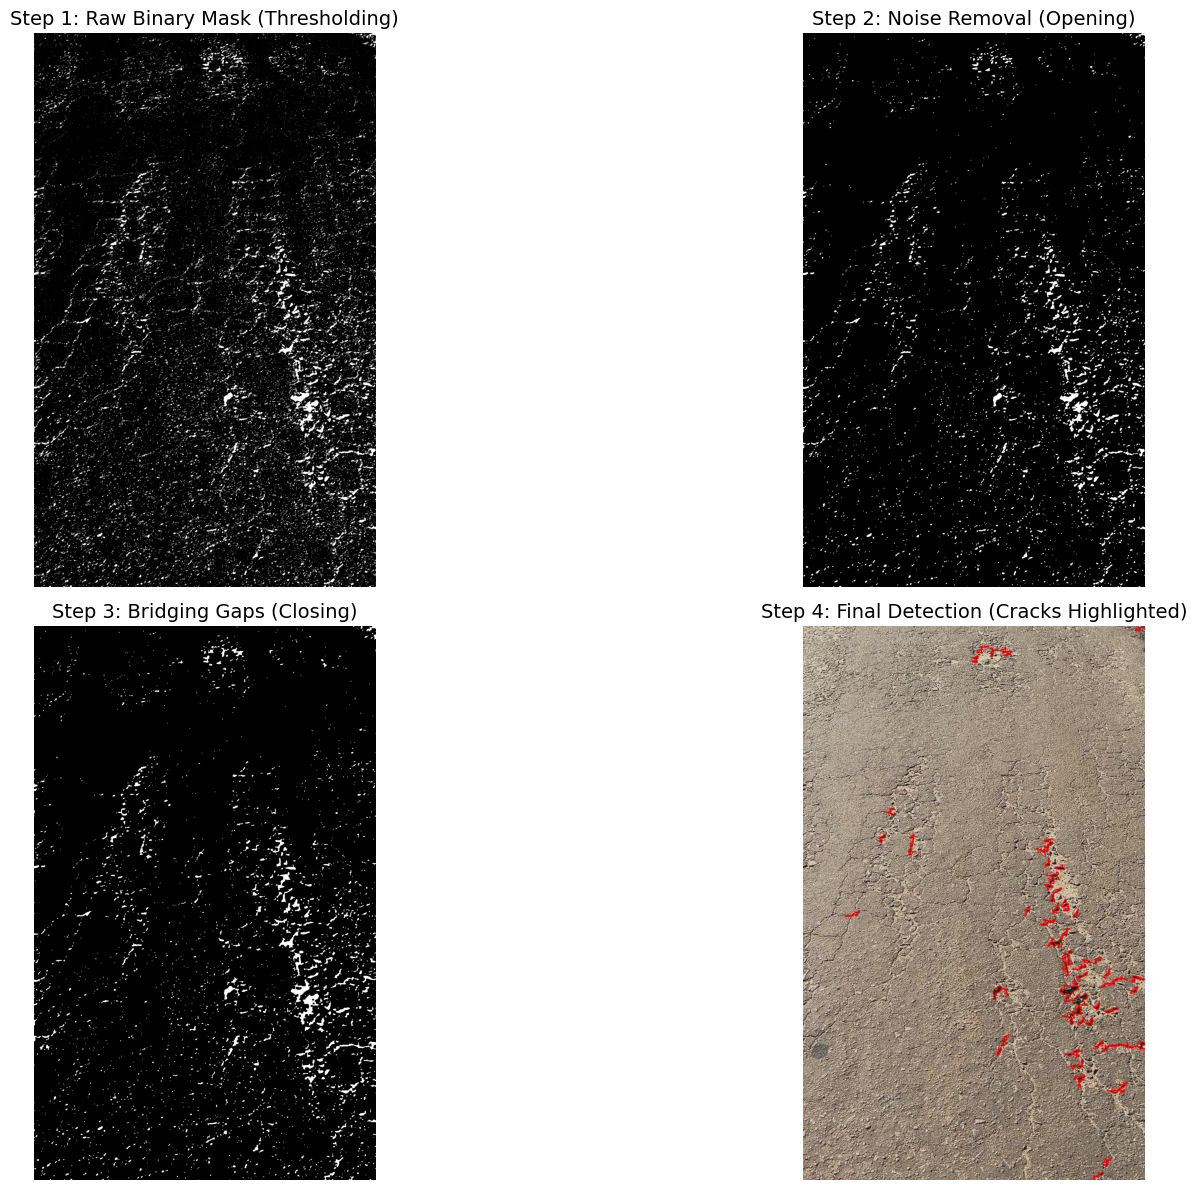

In [43]:
# Statistical Analysis
# Calculating the brightness (Mean) and contrast (Standard Deviation) 
# to understand how noisy or clear the image is.
mean_val = np.mean(final_enhanced)
std_val = np.std(final_enhanced)

# Coefficient of Variation (Ratio):
# This helps decide if we need heavy cleaning (Opening) or just connecting lines (Closing) based on the image's texture.
ratio = std_val / mean_val if mean_val != 0 else 0

# display the calculated value for manual check and validate if the program is working correctly
print(f"Contrast (Std): {std_val}")
print(f"Brightness (Mean): {mean_val}")
print(f"Variation Ratio: {ratio}")

# Binary Thresholding
# Separating the crack pixels from the road. 
# This creates a clear mask where the defects are isolated from the background.
_, crack_mask = cv2.threshold(final_enhanced, 35, 255, cv2.THRESH_BINARY_INV)


# We classify images into 3 categories based on their Variation Ratio to apply the most suitable cleaning and connecting filters.

if ratio > 0.6: 
    # Extremely High Contrast (Clear Images)
    # The crack is already prominent, so we avoid 'Opening' to prevent losing detail.
    print("High Contrast. Skipping Opening phase.")
    
    # For visualization consistency, we map 'cleaned' to the original mask.
    cleaned = crack_mask.copy() 
    
    # Using a small 3x3 kernel for a gentle 'Closing' to bridge tiny gaps.
    kernel_cl = np.ones((3,3), np.uint8)
    connected = cv2.morphologyEx(crack_mask, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
    
elif 0.4 < ratio <= 0.6: 
    # Medium Contrast (Mild Noise/Texture)
    # Requires a balance between cleaning and detail preservation.
    print(" Medium Contrast. Applying light cleaning.")
    
    # 'Opening' with a tiny 2x2 kernel to remove micro-noise without erasing fine cracks.
    kernel_small = np.ones((2,2), np.uint8) 
    cleaned = cv2.morphologyEx(crack_mask, cv2.MORPH_OPEN, kernel_small, iterations=1)
    
    # 'Closing' with a 5x5 kernel to strengthen the crack structure.
    kernel_cl = np.ones((3,3), np.uint8)
    connected = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel_cl, iterations=2)
    
else: 
    # Standard/Low Contrast (Fragmented or Noisy Images)
    # Cracks are likely broken into pixels; needs aggressive cleaning and merging.
    print("Standard/Low Contrast. Applying full cleaning.")
    
    # Standard 3x3 'Opening' to eliminate significant road surface artifacts.
    kernel = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(crack_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # Strong 9x9 'Closing' to bridge large gaps and merge fragmented red-dots into lines.
    kernel_cl = np.ones((9,9), np.uint8)
    connected = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel_cl, iterations=2)


# This function scans the binary mask and extracts the actual shapes of the cracks.
# It turns raw pixel data into a list of mathematical objects (contours) 
# that we can count, measure, and highlight on the final image.
contours, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Creating a duplicate of the original image for visualization.
# We draw our detections on this 'overlay'.
overlay = image.copy()

# Detection Filter & Visualization
# Iterating through each detected shape to filter out noise and highlight valid cracks.
for cnt in contours:
    # Calculating the surface area of the detected shape
    area = cv2.contourArea(cnt)
    
    # Noise is not highlighted
    # This ignores tiny dots or textures that aren't road defects.
    if area > 150:
        # Drawing the detection:
        cv2.drawContours(overlay, [cnt], -1, (0, 0, 255), 2)

# OpenCV uses BGR by default, but Matplotlib expects RGB.
# We must convert to ensure the red highlights appear correctly in the output.
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# Saving the final processed image to the local directory.
# Note: imwrite expects BGR (original 'overlay'), so we use that here.
cv2.imwrite("road_crack_result_f.png", overlay)


# ============================================================================
# Visualizing the Pipeline Results
# ============================================================================

plt.figure(figsize=(20, 12))

# thresholding image
plt.subplot(2, 2, 1)
plt.imshow(crack_mask, cmap='gray')
plt.title("Step 1: Raw Binary Mask (Thresholding)", fontsize=14)
plt.axis("off")

# After Morphological Cleaning (Opening)
plt.subplot(2, 2, 2)
display_cleaned = cleaned if 'cleaned' in locals() else crack_mask
plt.imshow(display_cleaned, cmap='gray')
plt.title("Step 2: Noise Removal (Opening)", fontsize=14)
plt.axis("off")

# 3. Final Connected Components (Closing)
plt.subplot(2, 2, 3)
plt.imshow(connected, cmap='gray')
plt.title("Step 3: Bridging Gaps (Closing)", fontsize=14)
plt.axis("off")

# 4. Final Detection
plt.subplot(2, 2, 4)
plt.imshow(overlay_rgb)
plt.title("Step 4: Final Detection (Cracks Highlighted)", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()